In [1]:
import scipy
import numpy as np
from collections import defaultdict
import networkx as nx
from tqdm import tqdm
from scipy import sparse
import pandas as pd
import pickle
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os

pesto_cutoff = 70
plddt_cutoff = 70

In [2]:
uniprot_human_df = pd.read_csv("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/uniprot/uniprotkb_AND_model_organism_9606_2024_12_16.tsv", sep="\t", usecols=['Entry', 'Entry Name', 'Protein names', 'Gene Names'])
uniprot_to_gene = dict(zip(uniprot_human_df['Entry'], uniprot_human_df['Gene Names']))
uniprot_to_protein_name = dict(zip(uniprot_human_df['Entry'], uniprot_human_df['Protein names']))

In [3]:
def random_walk_with_restart(G, A, seed_genes, r=0.75, tol=1e-6, max_iter=1000):
    """
    Perform Random Walk with Restart on a network.
    
    Parameters:
    G (nx.Graph): The input graph
    A (np.ndarray): Adjacency matrix of the PPI network
    seed_genes (list): List of seed genes (starting points for the random walk)
    r (float): Probability of restarting the walk
    tol (float): Convergence tolerance
    max_iter (int): Maximum number of iterations
    
    Returns:
    numpy.ndarray: Steady-state probabilities for each node
    """
    # Convert NetworkX graph to SciPy sparse matrix
    # A = nx.to_scipy_sparse_matrix(G, format='csr')
    A = sparse.csr_matrix(A)
    
    # Normalize the adjacency matrix
    D_inv = sparse.diags(1.0 / A.sum(axis=1).A1)
    W = D_inv @ A
    
    # Initialize the probability vector
    n = A.shape[0]
    p0 = np.zeros(n)
    for gene in seed_genes:
        if gene in G:
            p0[list(G.nodes()).index(gene)] = 1 / len(seed_genes)
    
    # Perform the random walk
    p = p0.copy()
    for _ in range(max_iter):
        p_next = (1 - r) * (W @ p) + r * p0
        if np.linalg.norm(p_next - p) < tol:
            return p_next
        p = p_next
    
    return p

In [4]:
chosen_diseases = pd.read_csv('/n/holylfs06/LABS/mzitnik_lab/Lab/afang/disease_network/open_target_2024_09/chosen_diseases.csv')
disease_associations = pd.read_csv('/n/holylfs06/LABS/mzitnik_lab/Lab/afang/disease_network/open_target_2024_09/association_by_overall_indirect_disease_counts_cutoff_0.5.csv')
disease_associations = disease_associations[disease_associations['diseaseId'].isin(chosen_diseases['diseaseId'])]
disease_id_to_name = dict(zip(disease_associations['diseaseId'], disease_associations['diseaseName']))
disease_name_to_id = dict(zip(disease_associations['diseaseName'], disease_associations['diseaseId']))
print("Number of unique diseases: ", len(disease_associations['diseaseId'].unique()))
disease_associations

Number of unique diseases:  105


,diseaseId,targetId,score,evidenceCount,uniprot_targetId,diseaseName
2754,MONDO_0015760,ENSG00000026103,0.511482,31,P25445,T-cell non-Hodgkin lymphoma
2755,MONDO_0015760,ENSG00000048052,0.520368,257,Q9UKV0,T-cell non-Hodgkin lymphoma
2756,MONDO_0015760,ENSG00000055609,0.507134,13,Q8NEZ4,T-cell non-Hodgkin lymphoma
2757,MONDO_0015760,ENSG00000061273,0.505264,14,Q8WUI4,T-cell non-Hodgkin lymphoma
2758,MONDO_0015760,ENSG00000068024,0.505264,14,P56524,T-cell non-Hodgkin lymphoma
...,...,...,...,...,...,...
182470,EFO_1002049,ENSG00000239732,0.544995,126,Q9NR96,glomerular disease
182471,EFO_1002049,ENSG00000244414,0.587819,67,Q03591,glomerular disease
182869,EFO_1002049,ENSG00000138760,0.695206,118,Q14108,glomerular disease
182870,EFO_1002049,ENSG00000148204,0.821178,73,Q5IJ48,glomerular disease


In [5]:
modality_disease_counts = pd.read_csv(f"/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/case_studies/network_analysis/modality_chosen_disease_counts_pesto_{pesto_cutoff}_plddt_{plddt_cutoff}.csv")
modality_disease_counts = pd.pivot_table(modality_disease_counts, 
                            values="num_proteins", 
                            index=['diseaseId', 'diseaseName'], 
                            columns='modality', 
                            fill_value=0)

In [6]:
# cut offs for 90% of the nodes
if pesto_cutoff == 80:
    modality_cutoff = {
        "protein": 0.998,
        "lipid": 0.996,
        "nucleic_acid": 0.996,
        "ligand": 0.989,
        "ion": 0.989,
    }
elif pesto_cutoff == 70:
    modality_cutoff = {
        "protein": 0.998,
        "lipid": 0.996,
        "nucleic_acid": 0.996,
        "ligand": 0.993,
        "ion": 0.988,
    }
else:
    raise NotImplementedError("not implemented for this plddt cutoff")

modality_graphs = {}

for modality, cutoff in modality_cutoff.items():
    # with open(f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/function/disgenet/embeddings/prot_interface_version_3_epoch10_step63085/embeddings_non_disease_PeSTo_80_{modality}.pkl", "rb") as f:
    #     non_disease_embeddings = pickle.load(f)

    # with open(f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/function/disgenet/embeddings/prot_interface_version_3_epoch10_step63085/embeddings_PeSTo_80_{modality}.pkl", "rb") as f:
    #     disease_embeddings = pickle.load(f)

    with open(f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/human_proteome/embeddings/pesto_{pesto_cutoff}_plddt_{plddt_cutoff}_{modality}.pkl", "rb") as f:
        embeddings_dataset = pickle.load(f)

    embeddings = np.array([x['graph_embedding'] for x in embeddings_dataset])
    uniprot_to_node_idx = {x['id']: i for i, x in enumerate(embeddings_dataset)}

    similarity_matrix = cosine_similarity(embeddings)

    indices = np.triu_indices_from(similarity_matrix, k=1)
    filtered_indices = indices[0][similarity_matrix[indices] > cutoff], indices[1][similarity_matrix[indices] > cutoff]

    print(f"-----------------{modality}-----------------")
    print("Number of embeddings: ", embeddings.shape)
    print("num edges: ", filtered_indices[0].shape[0])

    G = nx.Graph()
    G.add_nodes_from(range(len(embeddings)))
    edges = zip(filtered_indices[0], filtered_indices[1], similarity_matrix[filtered_indices])
    G.add_weighted_edges_from(edges)
    num_connected_components = nx.number_connected_components(G)
    size_of_largest_connected_component = max([len(x) for x in nx.connected_components(G)])
    whole_graph_density = nx.density(G)
    whole_graph_clustering = nx.average_clustering(G)
    print("size of largest connected component: ", size_of_largest_connected_component)
    print("proportion of largest connected component: ", size_of_largest_connected_component / len(embeddings))
    print("number of connected components", num_connected_components)
    print("density: ", whole_graph_density)
    print("clustering: ", whole_graph_clustering)
    print("average degree: ", np.mean([x[1] for x in G.degree()]))

    largest_component = max(nx.connected_components(G), key=len)
    largest_component_subgraph = G.subgraph(largest_component).copy()
    G = largest_component_subgraph

    adjacency_matrix = similarity_matrix > cutoff
    adjacency_matrix = adjacency_matrix.astype(int)
    largest_component_indices = sorted(list(largest_component))
    largest_component_adj_matrix = adjacency_matrix[np.ix_(largest_component_indices, largest_component_indices)]

    modality_graphs[modality] = {
        "graph": G,
        "uniprot_to_node_idx": uniprot_to_node_idx,
        "largest_component": largest_component,
        "filtered_indices": filtered_indices,
        "adjacency_matrix": largest_component_adj_matrix,
    }

-----------------protein-----------------
Number of embeddings:  (17158, 32)
num edges:  261677
size of largest connected component:  15421
proportion of largest connected component:  0.8987644247581303
number of connected components 1394
density:  0.001777818958138725
clustering:  0.4112212038699992
average degree:  30.502039864786106
-----------------lipid-----------------
Number of embeddings:  (6766, 32)
num edges:  157165
size of largest connected component:  6072
proportion of largest connected component:  0.8974283180608927
number of connected components 541
density:  0.006867300285611353
clustering:  0.4494486033806015
average degree:  46.45728643216081
-----------------nucleic_acid-----------------
Number of embeddings:  (6649, 32)
num edges:  114406
size of largest connected component:  6031
proportion of largest connected component:  0.907053692284554
number of connected components 500
density:  0.005176443206265557
clustering:  0.44947023297800404
average degree:  34.412994

In [7]:
chosen_disease = disease_name_to_id['prostate cancer']
cross_validation_assignments = []
for seed in range(100):
    np.random.seed(seed)
    disease_proteins = disease_associations[disease_associations['diseaseId'] == chosen_disease]['uniprot_targetId'].unique()
    disease_proteins = np.random.permutation(disease_proteins)
    num_folds = 5
    folds = np.array_split(disease_proteins, num_folds)
    for i in range(num_folds):
        train_proteins = np.concatenate([folds[j] for j in range(num_folds) if j != i])
        test_proteins = folds[i]
        cross_validation_assignments.append({
            "train": train_proteins,
            "test": test_proteins,
            "seed": seed,
            "fold": i
        })

In [ ]:
max_number_of_added_nodes = 500

results = []
for modality in ['ion', 'ligand', 'lipid', 'nucleic_acid', 'protein']:
    G = modality_graphs[modality]['graph']
    uniprot_to_node_idx = modality_graphs[modality]['uniprot_to_node_idx']
    node_idx_to_uniprot = {v: k for k, v in uniprot_to_node_idx.items()}
    largest_component = modality_graphs[modality]['largest_component']
    A = modality_graphs[modality]['adjacency_matrix']

    if modality_disease_counts.loc[chosen_disease, modality].values[0] < 25:
        print(f"not enough data for {modality}")
        continue

    for cv_split in tqdm(cross_validation_assignments, total=len(cross_validation_assignments), desc=modality):
        seed_proteins = cv_split['train']
        seed_nodes = [uniprot_to_node_idx[x] for x in seed_proteins if x in uniprot_to_node_idx and uniprot_to_node_idx[x] in largest_component]
        gt_proteins = cv_split['test']
        gt_nodes = [uniprot_to_node_idx[x] for x in gt_proteins if x in uniprot_to_node_idx and uniprot_to_node_idx[x] in largest_component]
        gt_proteins_in_graph = [node_idx_to_uniprot[x] for x in gt_nodes]
        
        p = random_walk_with_restart(G, A, seed_nodes)
        p_node_idx = np.array(list(sorted(largest_component)))
        rw_nodes = list(zip(p_node_idx, p))
        rw_nodes = [(node_idx, p) for node_idx, p in rw_nodes if not node_idx in seed_nodes]
        rw_nodes = sorted(rw_nodes, key=lambda x: x[1], reverse=True)[:min(max_number_of_added_nodes, len(rw_nodes))]
        added_node_indexes = [x[0] for x in rw_nodes]
        num_found_rw = len(set(added_node_indexes) & set(gt_nodes))
        recall_rw = num_found_rw/len(gt_nodes)
        found_rw_proteins = [node_idx_to_uniprot[x] for x in added_node_indexes]

        results.append({
            "seed": cv_split['seed'],
            "fold": cv_split['fold'],
            "found_rw_proteins": found_rw_proteins,
            "num_found_rw": num_found_rw,
            "recall_rw": recall_rw,
            "modality": modality,
        })

protein: 100%|██████████| 500/500 [07:35<00:00,  1.10it/s]


In [12]:
len(results)

2500

In [32]:
protein_ranks = defaultdict(list)
for result in results[2000:2500]:
    for i, protein in enumerate(result['found_rw_proteins']):
        protein_ranks[protein].append(i)
overall_protein_ranks = {k: np.mean(v) for k, v in protein_ranks.items()}
overall_protein_ranks = [x[0] for x in sorted(protein_ranks.items(), key=lambda x: x[1])]
protein_stds = {k: np.std(v) for k, v in protein_ranks.items()}

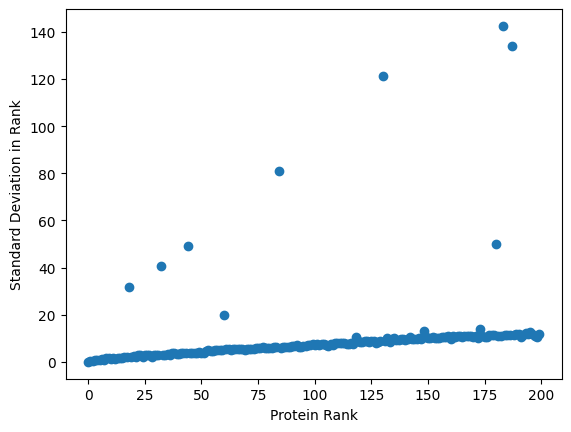

In [33]:
protein_to_rank = dict(zip(overall_protein_ranks, range(len(overall_protein_ranks))))
plt.scatter(range(200), [protein_stds[x] for x in overall_protein_ranks[:200]])
plt.xlabel("Protein Rank")
plt.ylabel("Standard Deviation in Rank")
plt.show()

In [34]:
disease_proteins = disease_associations[disease_associations['diseaseId'] == chosen_disease]['uniprot_targetId'].unique()

protein_rank_df = pd.DataFrame({'protein_rank': overall_protein_ranks})
protein_rank_df['gene'] = protein_rank_df['protein_rank'].apply(lambda x: uniprot_to_gene[x] if x in uniprot_to_gene else None)
protein_rank_df['protein_name'] = protein_rank_df['protein_rank'].apply(lambda x: uniprot_to_protein_name[x] if x in uniprot_to_protein_name else None)
protein_rank_df['std'] = protein_rank_df['protein_rank'].apply(lambda x: protein_stds[x])
protein_rank_df['in_disease'] = protein_rank_df['protein_rank'].apply(lambda x: x in disease_proteins)
protein_rank_df[protein_rank_df['in_disease']].head(20)

,protein_rank,gene,protein_name,std,in_disease


In [35]:
with open("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/human_proteome/disease_network_analysis/results_at_pesto_70_plddt_70_max_500_split_35.pkl", "rb") as f:
    results = pickle.load(f)

In [39]:
results['diseaseId']

0        OTAR_0000020
1        OTAR_0000020
2        OTAR_0000020
3        OTAR_0000020
4        OTAR_0000020
            ...      
1390    MONDO_0019053
1391    MONDO_0019053
1392    MONDO_0019053
1393    MONDO_0019053
1394    MONDO_0019053
Name: diseaseId, Length: 1395, dtype: object